# Stopping rules on the full sweep

A workbench for two questions the headline tables leave open:

1. **How do the scores behave across the parameter grid** — where does each one
   separate `inf` from `pers±`, and where does its null calibration hold?
2. **Which stopping rule actually controls error** — the fixed-$z$ rule is known
   to fail; this compares it against four alternatives on identical data.

Everything here is computed offline. The sweep ran every test as a *pure
observer* (`c = inf`), recording `Sus(t)` and `sigma_bar(t)` at every round, so
any stopping rule can be scored against the stored trajectories without
re-simulating.

## 0 — Setup, and the memory question

**Loading 8.91 M rows as a dataframe is the wrong move.** The existing notebooks
do `dataset(...).to_table().to_pandas()`, which costs ~2.0 GB resident and ~3.1 GB
peak for 12 columns. It fits, but barely, and it makes every operation a groupby
over 8.91 M rows.

The sweep has a perfectly regular shape — 297 cells x 200 sims x 150 rounds — so
it fits in dense `(59400, 150)` matrices instead. Two facts make the stopping-rule
work easy in that form. Writing $S_t=\sum_{i\le t}s_i$ and $V_t=\sum_{i\le t}\sigma_i^2$,

$$S_t = t\cdot\mathrm{Sus}(t), \qquad V_t = t\cdot\bar\sigma^2(t),$$

and the current rule $\mathrm{Sus}(t) > c\,\bar\sigma(t)/\sqrt{t}$ is exactly

$$S_t > c\sqrt{V_t}.$$

So every boundary becomes a function $B(t, V_t)$ compared against one matrix, fully
vectorised. Cost: **285 MB** for four float64 panels, versus ~2 GB — and a rule
evaluates in milliseconds rather than a groupby.

There is deliberately **no cache**. A stale `sim_summary.parquet` silently produced
wrong numbers once already in this project; loading takes ~15 s, which is not worth
that risk.

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path().resolve())
    while p != p.parent:
        if (p / 'experiments' / 'full_sweep').exists():
            return p
        p = p.parent
    raise RuntimeError('repo root not found')


ROOT = _find_repo_root()
SWEEP_DIR = ROOT / 'results' / 'full_sweep_v2'
TRAJ_DIR = SWEEP_DIR / 'trajectories'
OUT_DIR = SWEEP_DIR / 'analyses' / 'stopping_rules'
OUT_DIR.mkdir(parents=True, exist_ok=True)

T_MAX = 150
N_SIMS = 200
SCORES = ['surp2', 'sus1']
SCORE_LABEL = {'surp2': 'surp2', 'sus1': 'sus_1'}

# sus_1 uses the LTV-corrected variance; surp2 has only the one.
SIGMA_COL = {'surp2': 'surp2_sigma_bar2', 'sus1': 'sus1_sigma_bar2'}


def save(fig, name: str):
    fig.savefig(OUT_DIR / name, dpi=150, bbox_inches='tight')


print(f'repo   {ROOT}')
print(f'out    {OUT_DIR}')

repo   D:\Research\argumentative-awareness
out    D:\Research\argumentative-awareness\results\full_sweep_v2\analyses\stopping_rules


In [2]:
def load_panels(traj_dir: Path = TRAJ_DIR):
    """Stream the sweep into dense (n_sims, T) panels.

    Returns (meta, S, V) where meta is one row per simulation and S/V are dicts
    keyed by score holding the running sum and running variance-sum.

    Peak memory is one shard (~10 MB) plus the panels themselves, because shards
    are read and discarded one at a time.
    """
    shards = sorted(p for p in traj_dir.glob('cell=*/part.parquet'))
    if not shards:
        raise FileNotFoundError(f'no shards under {traj_dir}')
    n_cells = len(shards)
    n_rows = n_cells * N_SIMS

    S = {s: np.empty((n_rows, T_MAX), dtype=np.float64) for s in SCORES}
    V = {s: np.empty((n_rows, T_MAX), dtype=np.float64) for s in SCORES}
    meta = []

    cols = (['cell_id', 'sim_id', 'round', 'theta_star', 'psi_true', 'alpha']
            + [f'{s}_Sus' for s in SCORES] + [SIGMA_COL[s] for s in SCORES])

    t = np.arange(1, T_MAX + 1, dtype=np.float64)
    for k, path in enumerate(shards):
        d = pd.read_parquet(path, columns=cols)
        lo, hi = k * N_SIMS, (k + 1) * N_SIMS

        rnd = d['round'].to_numpy().reshape(N_SIMS, T_MAX)
        if not (rnd == t).all():
            raise ValueError(f'{path}: rows are not sim-major/round-minor')

        for s in SCORES:
            # Sus(t) = S_t/t and sigma_bar^2(t) = V_t/t, so multiply back by t.
            S[s][lo:hi] = d[f'{s}_Sus'].to_numpy().reshape(N_SIMS, T_MAX) * t
            V[s][lo:hi] = d[SIGMA_COL[s]].to_numpy().reshape(N_SIMS, T_MAX) * t

        first = d.iloc[::T_MAX]
        meta.append(pd.DataFrame({
            'cell_id': first['cell_id'].to_numpy(),
            'sim_id': first['sim_id'].to_numpy(),
            'theta_star': first['theta_star'].to_numpy(),
            'psi_true': first['psi_true'].to_numpy(),
            'alpha': first['alpha'].to_numpy(),
        }))
        del d

    meta = pd.concat(meta, ignore_index=True)
    meta['psi_true'] = meta['psi_true'].astype('category')
    return meta, S, V


%time meta, S, V = load_panels()

ROUNDS = np.arange(1, T_MAX + 1)
panel_mb = sum(a.nbytes for a in list(S.values()) + list(V.values())) / 1e6
print(f'\nsims           {len(meta):,}   ({meta.cell_id.nunique()} cells x {N_SIMS})')
print(f'panel memory   {panel_mb:.0f} MB   (vs ~2000 MB as a dataframe)')
print(f'meta memory    {meta.memory_usage(deep=True).sum()/1e6:.1f} MB')

CPU times: total: 4.83 s
Wall time: 2.94 s

sims           59,400   (297 cells x 200)
panel memory   285 MB   (vs ~2000 MB as a dataframe)
meta memory    2.0 MB


In [3]:
# Masks. alpha=1 is excluded from headline rates for comparability with S1 --
# at alpha=1 the pragmatic speaker is nearly literal, so there is almost no
# persuasion to detect. The panels keep every alpha; only this mask changes.
EXCLUDE_ALPHA_1 = True

USE = (meta['alpha'] != 1.0).to_numpy() if EXCLUDE_ALPHA_1 else np.ones(len(meta), bool)
IS_NULL = (meta['psi_true'] == 'inf').to_numpy()
IS_PP = (meta['psi_true'] == 'pers+').to_numpy()
IS_PM = (meta['psi_true'] == 'pers-').to_numpy()

NULL = USE & IS_NULL
ALT = USE & (IS_PP | IS_PM)

ALPHAS = np.array(sorted(meta.loc[USE, 'alpha'].unique()))
THETAS = np.array(sorted(meta['theta_star'].unique()))
CMAP = plt.get_cmap('viridis')
ACOLOR = {a: CMAP(i / max(1, len(ALPHAS) - 1)) for i, a in enumerate(ALPHAS)}

print(f'in use  {USE.sum():,} sims   null {NULL.sum():,}   alt {ALT.sum():,}')
print(f'alphas  {list(ALPHAS)}')

in use  54,000 sims   null 18,000   alt 36,000
alphas  [np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(7.0), np.float64(10.0), np.float64(15.0), np.float64(20.0)]


### Self-check — reproduce the published numbers

The panel form and the sum-form boundary are new machinery, so before trusting
anything below, `fixed_z` must reproduce `S1_headline_table.csv` exactly. If this
cell fails, the loader or the reshape is wrong and nothing downstream is valid.

In [4]:
def crossings(S_score, V_score, boundary, rows=None):
    '''First-crossing times for a boundary. Returns (fired, tau) over `rows`.'''
    s = S_score if rows is None else S_score[rows]
    v = V_score if rows is None else V_score[rows]
    b = boundary(ROUNDS, v)
    crossed = s > b
    fired = crossed.any(axis=1)
    tau = np.where(fired, crossed.argmax(axis=1) + 1, 0)
    return fired, tau


def fixed_z(c):
    '''The rule in rsa/detection/sequential_test.py: Sus(t) > c*sigma_bar(t)/sqrt(t).'''
    return lambda t, v: c * np.sqrt(np.maximum(v, 0.0))


_s1 = pd.read_csv(SWEEP_DIR / 'analyses' / 'substantive' / 'S1_headline_table.csv')
print(f'{"score":6} {"c":>4} | {"FPR":>16} | {"TPR pers+":>16}')
print('-' * 52)
_bad = 0
for _sc in SCORES:
    for _c in [2.0, 2.5, 3.0, 3.5]:
        _f, _ = crossings(S[_sc], V[_sc], fixed_z(_c), NULL)
        _p, _ = crossings(S[_sc], V[_sc], fixed_z(_c), USE & IS_PP)
        _row = _s1[(_s1.score == _sc) & (_s1.c == _c)].iloc[0]
        _ok = (round(_f.mean(), 3) == round(_row.FPR, 3)
               and round(_p.mean(), 3) == round(_row['TPR_pers+'], 3))
        _bad += (not _ok)
        print(f'{_sc:6} {_c:>4} | {_f.mean():.3f} vs {_row.FPR:.3f}    '
              f'| {_p.mean():.3f} vs {_row["TPR_pers+"]:.3f}    '
              f'{"OK" if _ok else "MISMATCH"}')
assert _bad == 0, f'{_bad} rows disagree with S1 -- panel/loader is wrong'
print('\nself-check PASSED: panel reproduces S1 exactly')

score     c |              FPR |        TPR pers+
----------------------------------------------------
surp2   2.0 | 0.234 vs 0.234    | 0.743 vs 0.743    OK


surp2   2.5 | 0.121 vs 0.121    | 0.699 vs 0.699    OK


surp2   3.0 | 0.069 vs 0.069    | 0.667 vs 0.667    OK
surp2   3.5 | 0.034 vs 0.034    | 0.635 vs 0.635    OK


sus1    2.0 | 0.219 vs 0.219    | 0.996 vs 0.996    OK


sus1    2.5 | 0.128 vs 0.128    | 0.989 vs 0.989    OK
sus1    3.0 | 0.065 vs 0.065    | 0.974 vs 0.974    OK


sus1    3.5 | 0.031 vs 0.031    | 0.947 vs 0.947    OK

self-check PASSED: panel reproduces S1 exactly


## 1 — Score behaviour across the parameter grid

Four views, all on the null unless stated: does `Sus(t)` go where it should, is
the variance honest, how far apart are the null and alternative at the horizon,
and where in $(\theta^\star,\alpha)$ does each score actually separate.

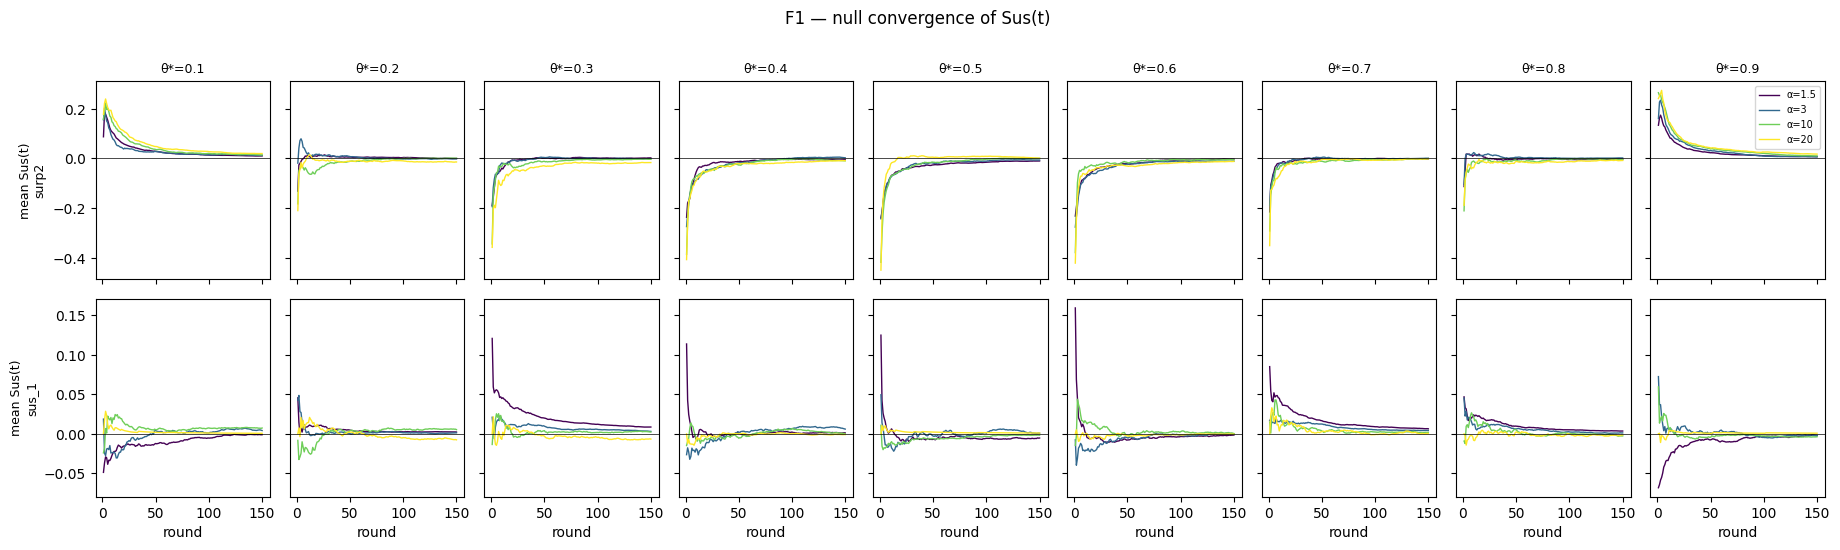

In [5]:
# F1 -- null convergence of Sus(t), per theta*, coloured by alpha.
ALPHA_SHOW = [1.5, 3.0, 10.0, 20.0]
fig, axes = plt.subplots(2, len(THETAS), figsize=(2.05 * len(THETAS), 5.4),
                         sharex=True, sharey='row', squeeze=False)
for j, th in enumerate(THETAS):
    for r, sc in enumerate(SCORES):
        ax = axes[r, j]
        for a in ALPHA_SHOW:
            rows = NULL & (meta['theta_star'] == th).to_numpy() & (meta['alpha'] == a).to_numpy()
            if not rows.any():
                continue
            ax.plot(ROUNDS, (S[sc][rows] / ROUNDS).mean(axis=0),
                    color=ACOLOR[a], lw=1.0, label=f'α={a:g}')
        ax.axhline(0, color='k', lw=0.5)
        if r == 0:
            ax.set_title(f'θ*={th:g}', fontsize=9)
        if r == 1:
            ax.set_xlabel('round')
for r, sc in enumerate(SCORES):
    axes[r, 0].set_ylabel(f'mean Sus(t)\n{SCORE_LABEL[sc]}', fontsize=9)
axes[0, -1].legend(fontsize=7, loc='best')
fig.suptitle('F1 — null convergence of Sus(t)', y=1.01)
fig.tight_layout()
save(fig, 'F1_null_convergence.png')
plt.show()

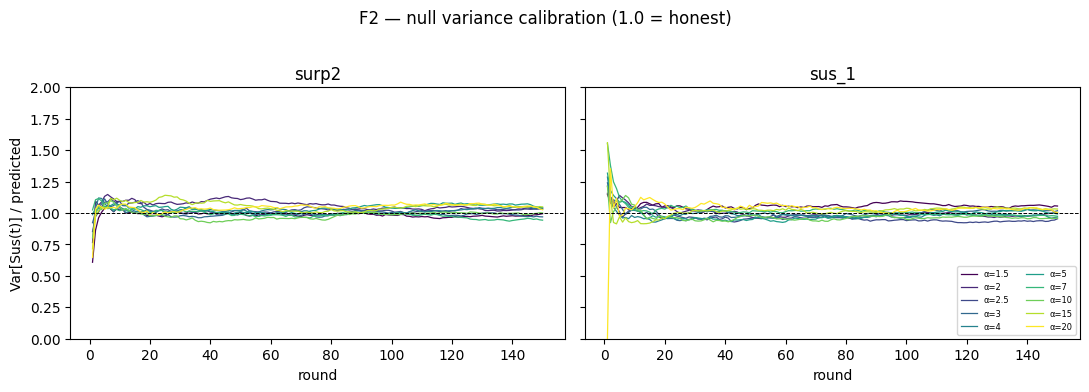

In [6]:
# F2 -- null variance calibration: Var[Sus(t)] vs the predicted V_t/t^2.
# An honest variance gives ratio ~1 at every round.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, sc in zip(axes, SCORES):
    for a in ALPHAS:
        rows = NULL & (meta['alpha'] == a).to_numpy()
        emp = (S[sc][rows] / ROUNDS).var(axis=0, ddof=1)
        pred = V[sc][rows].mean(axis=0) / ROUNDS ** 2
        ax.plot(ROUNDS, emp / pred, color=ACOLOR[a], lw=0.9, label=f'α={a:g}')
    ax.axhline(1.0, color='k', lw=0.7, ls='--')
    ax.set_title(SCORE_LABEL[sc])
    ax.set_xlabel('round')
    ax.set_ylim(0, 2)
axes[0].set_ylabel('Var[Sus(t)] / predicted')
axes[1].legend(fontsize=6, ncol=2, loc='lower right')
fig.suptitle('F2 — null variance calibration (1.0 = honest)', y=1.02)
fig.tight_layout()
save(fig, 'F2_variance_calibration.png')
plt.show()

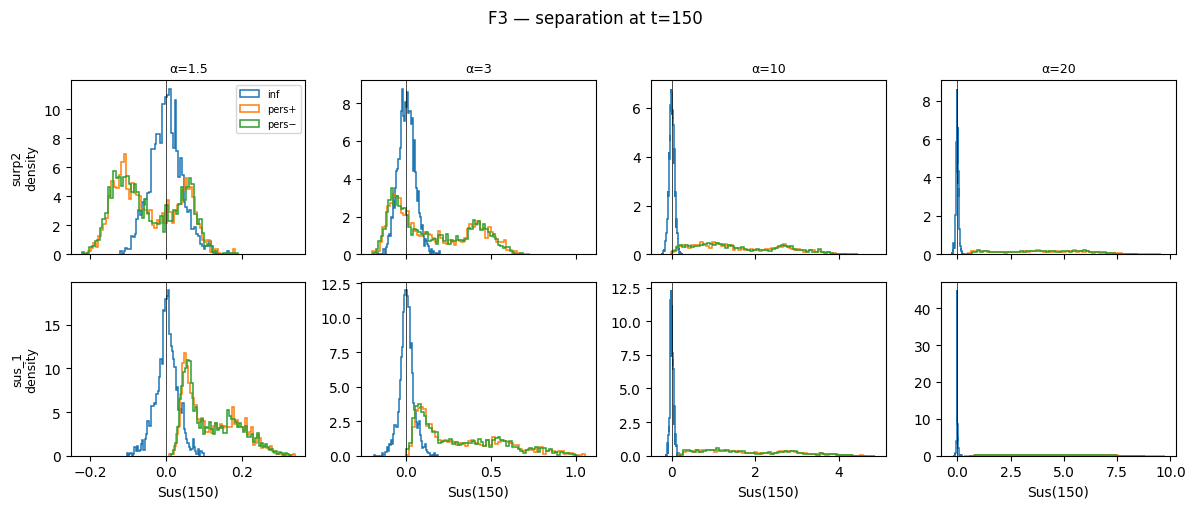

In [7]:
# F3 -- separation at the horizon: Sus(150) under null vs pers+/pers-.
fig, axes = plt.subplots(2, len(ALPHA_SHOW), figsize=(3.0 * len(ALPHA_SHOW), 5.0),
                         sharex='col', squeeze=False)
for j, a in enumerate(ALPHA_SHOW):
    am = (meta['alpha'] == a).to_numpy()
    for r, sc in enumerate(SCORES):
        ax = axes[r, j]
        for rows, lab, col in [(NULL & am, 'inf', 'tab:blue'),
                               (USE & IS_PP & am, 'pers+', 'tab:orange'),
                               (USE & IS_PM & am, 'pers−', 'tab:green')]:
            if rows.any():
                ax.hist(S[sc][rows][:, -1] / T_MAX, bins=60, histtype='step',
                        density=True, color=col, lw=1.1, label=lab)
        ax.axvline(0, color='k', lw=0.5)
        if r == 0:
            ax.set_title(f'α={a:g}', fontsize=9)
        if r == 1:
            ax.set_xlabel('Sus(150)')
for r, sc in enumerate(SCORES):
    axes[r, 0].set_ylabel(f'{SCORE_LABEL[sc]}\ndensity', fontsize=9)
axes[0, 0].legend(fontsize=7)
fig.suptitle('F3 — separation at t=150', y=1.01)
fig.tight_layout()
save(fig, 'F3_separation.png')
plt.show()

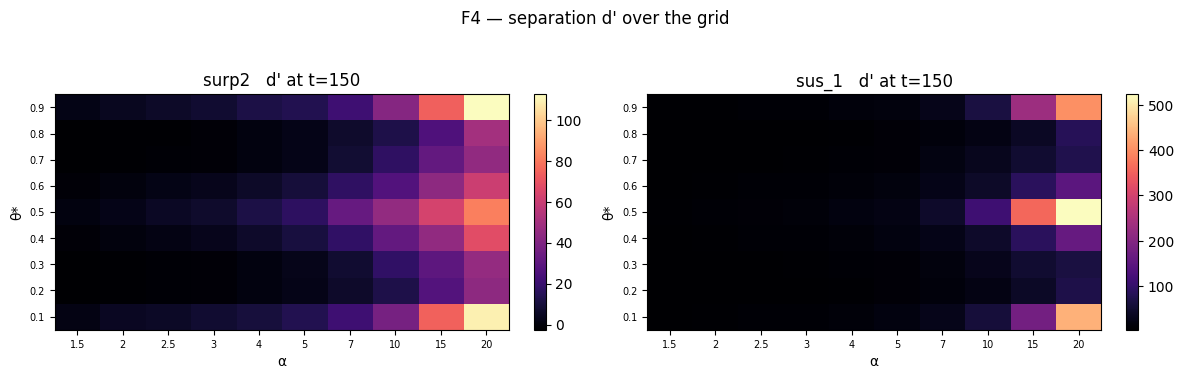

median d' —  surp2: 7.16   sus_1: 11.99


In [8]:
# F4 -- d' = (E[Sus|alt] - E[Sus|null]) / sd(Sus|null) at t=150, over the grid.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
dprime = {}
for ax, sc in zip(axes, SCORES):
    M = np.full((len(THETAS), len(ALPHAS)), np.nan)
    for i, th in enumerate(THETAS):
        tm = (meta['theta_star'] == th).to_numpy()
        for j, a in enumerate(ALPHAS):
            am = tm & (meta['alpha'] == a).to_numpy()
            n, p = NULL & am, ALT & am
            if n.any() and p.any():
                sd = (S[sc][n][:, -1] / T_MAX).std(ddof=1)
                if sd > 0:
                    M[i, j] = ((S[sc][p][:, -1] / T_MAX).mean()
                               - (S[sc][n][:, -1] / T_MAX).mean()) / sd
    dprime[sc] = M
    im = ax.imshow(M, aspect='auto', origin='lower', cmap='magma')
    ax.set_xticks(range(len(ALPHAS)), [f'{a:g}' for a in ALPHAS], fontsize=7)
    ax.set_yticks(range(len(THETAS)), [f'{t:g}' for t in THETAS], fontsize=7)
    ax.set_xlabel('α'); ax.set_ylabel('θ*')
    ax.set_title(f"{SCORE_LABEL[sc]}   d' at t=150")
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("F4 — separation d' over the grid", y=1.04)
fig.tight_layout()
save(fig, 'F4_dprime_grid.png')
plt.show()

print("median d' —  " + "   ".join(
    f'{SCORE_LABEL[s]}: {np.nanmedian(dprime[s]):.2f}' for s in SCORES))

## 2 — Stopping rules

Each rule is a boundary $B(t,V_t)$; the test fires at the first $t$ with
$S_t > B(t,V_t)$. All are evaluated on identical trajectories.

| rule | boundary | idea |
|---|---|---|
| `fixed_z(c)` | $c\sqrt{V_t}$ | the current rule; known to over-fire |
| `warmup(c,t_0)` | $c\sqrt{V_t}$ for $t\ge t_0$ | Group 1's cheap insurance |
| `lil(c)` | $c\sqrt{2V_t\log\log t}$ | law of iterated logarithm |
| `robbins(\delta,\rho)` | $\sqrt{(V_t+\rho)\log\frac{V_t+\rho}{\rho\delta^2}}$ | anytime-valid normal mixture |
| `empirical(\delta,T)` | $c_\delta\sqrt{V_t}$, $c_\delta$ from null quantiles | horizon-committed calibration |

`robbins` is the only one with an *a priori* guarantee: under a null where $S_t$ is
a martingale with variance process $V_t$, $\Pr(\exists t: S_t \ge B) \le \delta$ for
any horizon. `empirical` is calibrated on a **train split** of the null sims and
scored on a held-out split — calibrating and reporting on the same sims would make
its FPR meet the target by construction.

In [9]:
def warmup(c, t0):
    return lambda t, v: np.where(t >= t0, c * np.sqrt(np.maximum(v, 0.0)), np.inf)


def lil(c):
    # log log t needs t >= 3 to stay positive.
    return lambda t, v: c * np.sqrt(2.0 * np.maximum(v, 0.0)
                                    * np.log(np.log(np.maximum(t, 3.0))))


def robbins(delta, rho):
    '''Robbins normal-mixture boundary; Pr(ever cross) <= delta under the null.'''
    def b(t, v):
        w = np.maximum(v, 0.0) + rho
        return np.sqrt(w * np.log(np.maximum(w / (rho * delta ** 2), 1.0 + 1e-12)))
    return b


def empirical_c(score, delta, rows_train):
    '''(1-delta) quantile of max_t S_t/sqrt(V_t) over training null sims.'''
    s, v = S[score][rows_train], V[score][rows_train]
    z = np.where(v > 0, s / np.sqrt(np.maximum(v, 1e-300)), -np.inf)
    return float(np.quantile(z.max(axis=1), 1.0 - delta))


# rho controls where the mixture boundary is tightest; set it to the typical
# accumulated variance at the horizon so it is sharp where we actually stop.
RHO = {sc: float(np.median(V[sc][NULL][:, -1])) for sc in SCORES}
print('robbins rho (median V at t=150):  '
      + '   '.join(f'{SCORE_LABEL[s]}: {RHO[s]:.2f}' for s in SCORES))

# Held-out split for the empirical rule: even sim_id calibrates, odd is scored.
TRAIN = NULL & (meta['sim_id'].to_numpy() % 2 == 0)
TEST_NULL = NULL & (meta['sim_id'].to_numpy() % 2 == 1)
print(f'empirical split: {TRAIN.sum():,} train nulls / {TEST_NULL.sum():,} test nulls')

robbins rho (median V at t=150):  surp2: 63.72   sus_1: 35.11
empirical split: 9,000 train nulls / 9,000 test nulls


In [10]:
def evaluate(score, boundary, null_rows=None, alt_rows=None):
    '''FPR / TPR / latency / FPR-vs-t for one rule on one score.'''
    null_rows = NULL if null_rows is None else null_rows
    alt_rows = ALT if alt_rows is None else alt_rows

    f_n, _ = crossings(S[score], V[score], boundary, null_rows)
    f_p, tau_p = crossings(S[score], V[score], boundary, USE & IS_PP)
    f_m, tau_m = crossings(S[score], V[score], boundary, USE & IS_PM)

    # FPR as a function of horizon: has this null sim crossed by round t?
    b = boundary(ROUNDS, V[score][null_rows])
    fpr_t = np.maximum.accumulate(S[score][null_rows] > b, axis=1).mean(axis=0)

    tau = np.concatenate([tau_p[f_p], tau_m[f_m]])
    return {
        'FPR': float(f_n.mean()),
        'TPR_pers+': float(f_p.mean()),
        'TPR_pers-': float(f_m.mean()),
        'TPR_avg': float(0.5 * (f_p.mean() + f_m.mean())),
        'median_tau': float(np.median(tau)) if tau.size else np.nan,
        'fpr_t': fpr_t,
    }


DELTA = 0.05

RULES = {}
for sc in SCORES:
    ce = empirical_c(sc, DELTA, TRAIN)
    RULES[sc] = {
        'fixed_z c=2':      (fixed_z(2.0), NULL),
        'fixed_z c=3.5':    (fixed_z(3.5), NULL),
        'warmup c=3.5,t≥10': (warmup(3.5, 10), NULL),
        'LIL c=2':          (lil(2.0), NULL),
        f'Robbins δ={DELTA}': (robbins(DELTA, RHO[sc]), NULL),
        f'empirical δ={DELTA} (c={ce:.2f}, held-out)': (fixed_z(ce), TEST_NULL),
    }

rows = []
for sc in SCORES:
    for name, (b, nrows) in RULES[sc].items():
        r = evaluate(sc, b, null_rows=nrows)
        rows.append({'score': SCORE_LABEL[sc], 'rule': name, **{
            k: v for k, v in r.items() if k != 'fpr_t'}})
summary = pd.DataFrame(rows)
summary.to_csv(OUT_DIR / 'R1_rule_comparison.csv', index=False)
summary.round(3)

,score,rule,FPR,TPR_pers+,TPR_pers-,TPR_avg,median_tau
0,surp2,fixed_z c=2,0.234,0.743,0.740,0.741,3.0
1,surp2,fixed_z c=3.5,0.034,0.635,0.636,0.635,5.0
2,surp2,"warmup c=3.5,t≥10",0.015,0.628,0.630,0.629,10.0
3,surp2,LIL c=2,0.331,0.727,0.729,0.728,1.0
4,surp2,Robbins δ=0.05,0.002,0.589,0.592,0.591,17.0
5,surp2,"empirical δ=0.05 (c=3.34, held-out)",0.042,0.646,0.647,0.646,4.0
6,sus_1,fixed_z c=2,0.219,0.996,0.995,0.995,2.0
7,sus_1,fixed_z c=3.5,0.031,0.947,0.947,0.947,5.0
8,sus_1,"warmup c=3.5,t≥10",0.016,0.946,0.946,0.946,10.0
9,sus_1,LIL c=2,0.268,0.974,0.972,0.973,1.0


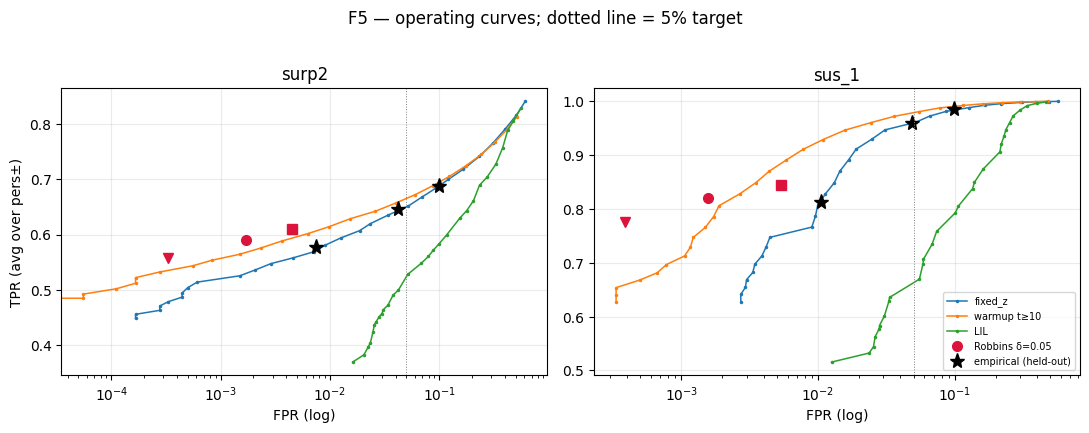

In [11]:
# F5 -- operating curves: sweep each rule's parameter, plot FPR vs TPR.
GRID = np.linspace(1.0, 8.0, 29)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
curves = {}
for ax, sc in zip(axes, SCORES):
    for label, mk in [('fixed_z', lambda c: fixed_z(c)),
                      ('warmup t≥10', lambda c: warmup(c, 10)),
                      ('LIL', lambda c: lil(c))]:
        xs, ys = [], []
        for c in GRID:
            r = evaluate(sc, mk(c))
            xs.append(r['FPR']); ys.append(r['TPR_avg'])
        curves[(sc, label)] = (np.array(xs), np.array(ys))
        ax.plot(xs, ys, marker='.', ms=3, lw=1.1, label=label)
    for d, m in [(0.01, 'v'), (0.05, 'o'), (0.10, 's')]:
        r = evaluate(sc, robbins(d, RHO[sc]))
        ax.plot(r['FPR'], r['TPR_avg'], m, ms=7, color='crimson',
                label=f'Robbins δ={d}' if d == 0.05 else None)
    for d in [0.01, 0.05, 0.10]:
        ce = empirical_c(sc, d, TRAIN)
        r = evaluate(sc, fixed_z(ce), null_rows=TEST_NULL)
        ax.plot(r['FPR'], r['TPR_avg'], '*', ms=11, color='black',
                label='empirical (held-out)' if d == 0.05 else None)
    ax.axvline(0.05, color='grey', lw=0.7, ls=':')
    ax.set_xscale('log')
    ax.set_xlabel('FPR (log)'); ax.set_title(SCORE_LABEL[sc])
    ax.grid(alpha=0.25)
axes[0].set_ylabel('TPR (avg over pers±)')
axes[1].legend(fontsize=7, loc='lower right')
fig.suptitle('F5 — operating curves; dotted line = 5% target', y=1.02)
fig.tight_layout()
save(fig, 'F5_operating_curves.png')
plt.show()

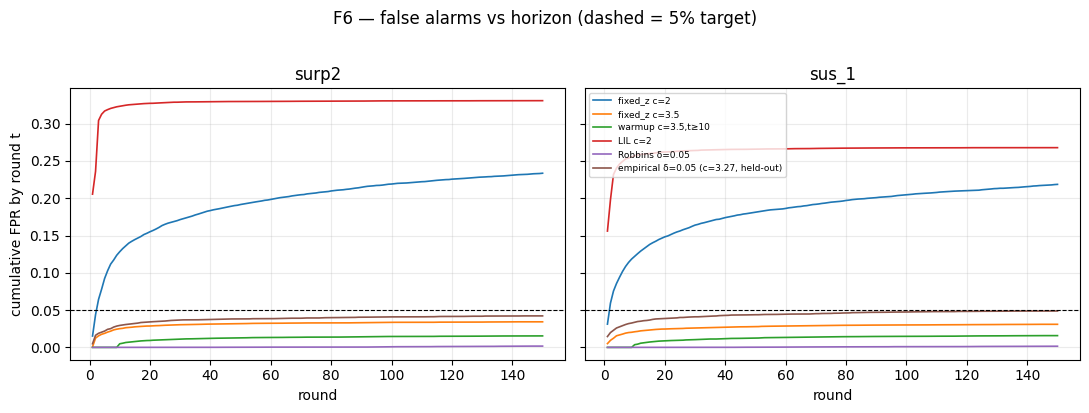

In [12]:
# F6 -- how false alarms accumulate over the horizon. A rule that controls error
# at T=150 should be flat-ish; the fixed-z failure mode is a curve that keeps rising.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
for ax, sc in zip(axes, SCORES):
    for name, (b, nrows) in RULES[sc].items():
        r = evaluate(sc, b, null_rows=nrows)
        ax.plot(ROUNDS, r['fpr_t'], lw=1.2, label=name)
    ax.axhline(DELTA, color='k', ls='--', lw=0.8)
    ax.set_xlabel('round'); ax.set_title(SCORE_LABEL[sc]); ax.grid(alpha=0.25)
axes[0].set_ylabel('cumulative FPR by round t')
axes[1].legend(fontsize=6.5, loc='upper left')
fig.suptitle('F6 — false alarms vs horizon (dashed = 5% target)', y=1.02)
fig.tight_layout()
save(fig, 'F6_fpr_vs_horizon.png')
plt.show()

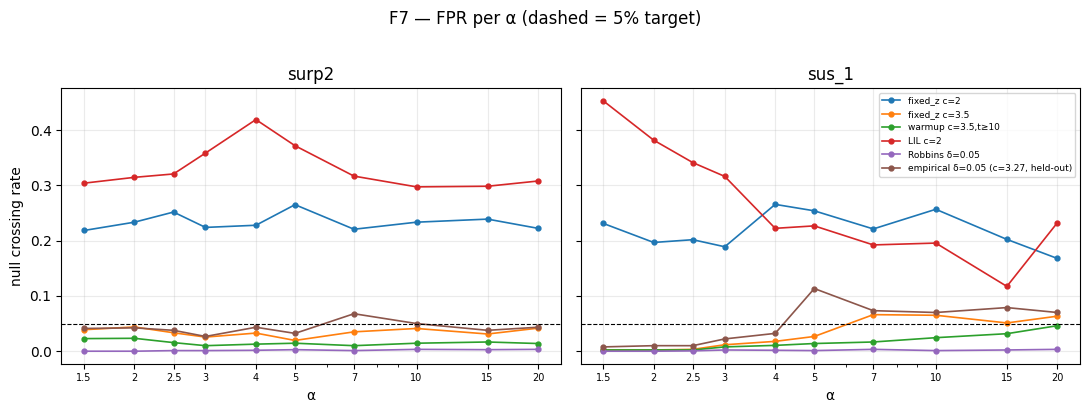

spread of FPR across α (smaller = more uniform across the grid):
                                             max−min
surp2 · Robbins δ=0.05                         0.003
sus_1 · Robbins δ=0.05                         0.003
surp2 · warmup c=3.5,t≥10                      0.013
surp2 · fixed_z c=3.5                          0.024
surp2 · empirical δ=0.05 (c=3.34, held-out)    0.041
sus_1 · warmup c=3.5,t≥10                      0.044
surp2 · fixed_z c=2                            0.047
sus_1 · fixed_z c=3.5                          0.064
sus_1 · fixed_z c=2                            0.098
sus_1 · empirical δ=0.05 (c=3.27, held-out)    0.106
surp2 · LIL c=2                                0.122
sus_1 · LIL c=2                                0.336


In [13]:
# F7 -- the U-shape. Fixed-z FPR is non-monotone in alpha; does any rule flatten it?
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
per_alpha = {}
for ax, sc in zip(axes, SCORES):
    for name, (b, nrows) in RULES[sc].items():
        ys = []
        for a in ALPHAS:
            rows = nrows & (meta['alpha'] == a).to_numpy()
            f, _ = crossings(S[sc], V[sc], b, rows)
            ys.append(f.mean())
        per_alpha[(sc, name)] = np.array(ys)
        ax.plot(ALPHAS, ys, marker='o', ms=3.5, lw=1.2, label=name)
    ax.axhline(DELTA, color='k', ls='--', lw=0.8)
    ax.set_xscale('log'); ax.set_xticks(ALPHAS)
    ax.set_xticklabels([f'{a:g}' for a in ALPHAS], fontsize=7)
    ax.set_xlabel('α'); ax.set_title(SCORE_LABEL[sc]); ax.grid(alpha=0.25)
axes[0].set_ylabel('null crossing rate')
axes[1].legend(fontsize=6.5)
fig.suptitle('F7 — FPR per α (dashed = 5% target)', y=1.02)
fig.tight_layout()
save(fig, 'F7_fpr_per_alpha.png')
plt.show()

flat = pd.DataFrame({f'{SCORE_LABEL[s]} · {n}': v
                     for (s, n), v in per_alpha.items()}, index=ALPHAS).T
flat['max−min'] = flat.max(axis=1) - flat.min(axis=1)
print('spread of FPR across α (smaller = more uniform across the grid):')
print(flat[['max−min']].sort_values('max−min').round(3).to_string())

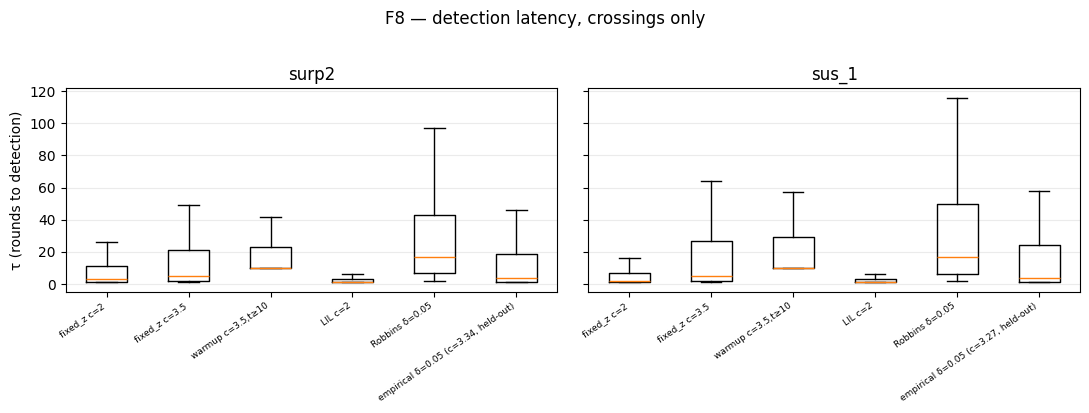

In [14]:
# F8 -- detection latency on the alternative, for rules that control FPR.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
for ax, sc in zip(axes, SCORES):
    labels, data = [], []
    for name, (b, _n) in RULES[sc].items():
        f_p, tau_p = crossings(S[sc], V[sc], b, USE & IS_PP)
        f_m, tau_m = crossings(S[sc], V[sc], b, USE & IS_PM)
        tau = np.concatenate([tau_p[f_p], tau_m[f_m]])
        if tau.size:
            labels.append(name); data.append(tau)
    ax.boxplot(data, tick_labels=labels, showfliers=False, vert=True)
    ax.set_title(SCORE_LABEL[sc]); ax.tick_params(axis='x', rotation=35, labelsize=6.5)
    ax.grid(alpha=0.25, axis='y')
    for lab in ax.get_xticklabels():
        lab.set_ha('right')
axes[0].set_ylabel('τ (rounds to detection)')
fig.suptitle('F8 — detection latency, crossings only', y=1.02)
fig.tight_layout()
save(fig, 'F8_latency.png')
plt.show()

### The comparison that matters: matched *actual* FPR

Comparing rules at matched *nominal* level is unfair to the conservative ones.
`robbins` carries a genuine anytime guarantee, so it spends its budget on the
worst case and lands far under target — 0.2% actual against a 0.05 nominal. Read
naively that looks like weak power; really it means the knob is set too tight.

The honest comparison calibrates every rule to the **same achieved false-alarm
rate**, then asks which retains the most power and which is most uniform across
$\alpha$. Some rules *cannot* reach the target at any parameter value — that is
itself a result.

In [15]:
def calibrate(score, mk, lo, hi, target=0.05, fpr_rises_with_param=True,
              null_rows=None, iters=48):
    # Bisect a rule's parameter until its achieved FPR hits `target`.
    # Returns (param, saturated): saturated means the search ran into the end of
    # the bracket, i.e. no parameter in range reaches the target.
    lo0, hi0 = lo, hi
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        f = evaluate(score, mk(mid), null_rows=null_rows)['FPR']
        if (f < target) == fpr_rises_with_param:
            lo = mid
        else:
            hi = mid
    par = 0.5 * (lo + hi)
    # Saturation means the bisect pinned to an endpoint of the bracket. Measure
    # that against the endpoint values themselves -- comparing against a
    # fraction of the span misreads a genuine solution in a wide bracket
    # (e.g. Robbins delta=0.4 inside [1e-4, 500]) as pinned to the floor.
    saturated = (par >= hi0 * (1 - 1e-6)) or (par <= lo0 * (1 + 1e-6))
    return par, saturated


TARGET = 0.05
_rows = []
for sc in SCORES:
    specs = [
        ('fixed_z',      lambda c, _s=sc: fixed_z(c),           1.0,  200.0, False),
        ('warmup t>=10', lambda c, _s=sc: warmup(c, 10),        1.0,  200.0, False),
        ('LIL',          lambda c, _s=sc: lil(c),               0.5,  200.0, False),
        ('Robbins',      lambda d, _s=sc: robbins(d, RHO[_s]),  1e-4, 500.0, True),
    ]
    for name, mk, lo, hi, rises in specs:
        # Calibrate on the TRAIN nulls and report FPR on the held-out half.
        # Calibrating and scoring on the same sims would force FPR to the target
        # by construction and tell us nothing.
        par, sat = calibrate(sc, mk, lo, hi, TARGET, rises, null_rows=TRAIN)
        r = evaluate(sc, mk(par), null_rows=TEST_NULL)
        per_a = [crossings(S[sc], V[sc], mk(par),
                           TEST_NULL & (meta['alpha'] == a).to_numpy())[0].mean()
                 for a in ALPHAS]
        _rows.append({
            'score': SCORE_LABEL[sc], 'rule': name, 'param': round(par, 3),
            'FPR': r['FPR'], 'TPR_avg': r['TPR_avg'],
            'median_tau': r['median_tau'],
            'alpha_spread': max(per_a) - min(per_a),
            'controls_FPR': bool(r['FPR'] <= TARGET * 1.15 and not sat),
        })

matched = pd.DataFrame(_rows)
matched.to_csv(OUT_DIR / 'R2_matched_fpr.csv', index=False)
print(f'Calibrated on {TRAIN.sum():,} train nulls, FPR scored on {TEST_NULL.sum():,} held-out nulls.')
print('controls_FPR=False means the search hit the end of its parameter bracket')
print('without getting there -- no setting of that rule delivers 5% on this data.')
matched.round(3)

Calibrated on 9,000 train nulls, FPR scored on 9,000 held-out nulls.
controls_FPR=False means the search hit the end of its parameter bracket
without getting there -- no setting of that rule delivers 5% on this data.


,score,rule,param,FPR,TPR_avg,median_tau,alpha_spread,controls_FPR
0,surp2,fixed_z,3.341,0.042,0.646,4.0,0.041,True
1,surp2,warmup t>=10,2.868,0.051,0.665,10.0,0.026,True
2,surp2,LIL,4.912,0.046,0.516,2.0,0.047,True
3,surp2,Robbins,0.409,0.053,0.669,10.0,0.058,True
4,sus_1,fixed_z,3.275,0.049,0.959,4.0,0.106,True
5,sus_1,warmup t>=10,2.790,0.052,0.979,10.0,0.058,True
6,sus_1,LIL,5.916,0.046,0.647,1.0,0.148,True
7,sus_1,Robbins,0.421,0.051,0.930,11.0,0.056,True


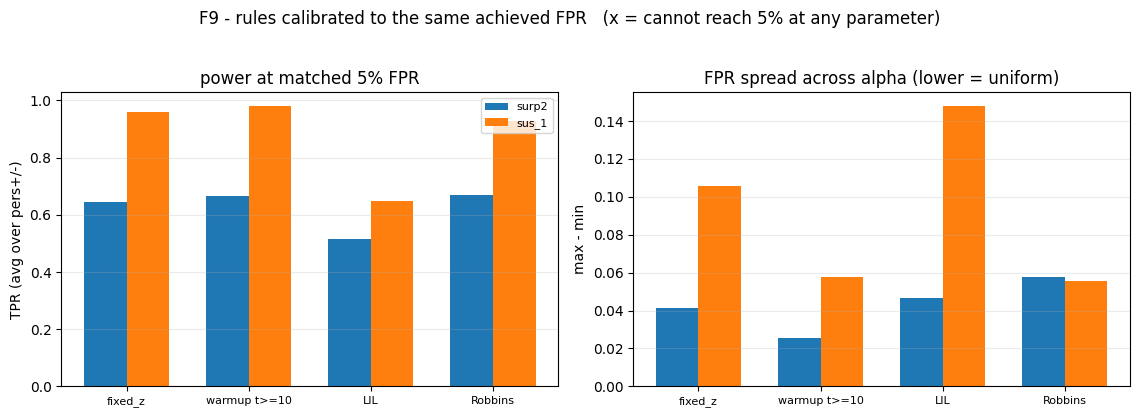

In [16]:
# F9 -- power and alpha-uniformity once every rule sits at the same achieved FPR.
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
w = 0.35
labels = matched[matched.score == SCORE_LABEL[SCORES[0]]]['rule'].tolist()
for k, sc in enumerate(SCORES):
    sub = matched[matched.score == SCORE_LABEL[sc]].reset_index(drop=True)
    x = np.arange(len(sub))
    axes[0].bar(x + (k - 0.5) * w, sub['TPR_avg'], w, label=SCORE_LABEL[sc])
    axes[1].bar(x + (k - 0.5) * w, sub['alpha_spread'], w, label=SCORE_LABEL[sc])
    for ax, col in [(axes[0], 'TPR_avg'), (axes[1], 'alpha_spread')]:
        for xi in range(len(sub)):
            if not sub.loc[xi, 'controls_FPR']:
                ax.text(xi + (k - 0.5) * w, sub.loc[xi, col], 'x', ha='center',
                        va='bottom', fontsize=11, color='crimson', weight='bold')
for ax, ttl, yl in [(axes[0], 'power at matched 5% FPR', 'TPR (avg over pers+/-)'),
                    (axes[1], 'FPR spread across alpha (lower = uniform)', 'max - min')]:
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(ttl); ax.set_ylabel(yl); ax.grid(alpha=0.25, axis='y')
axes[0].legend(fontsize=8)
fig.suptitle('F9 - rules calibrated to the same achieved FPR   (x = cannot reach 5% at any parameter)',
             y=1.03)
fig.tight_layout()
save(fig, 'F9_matched_fpr.png')
plt.show()

## 3 — Reading the comparison

Two tables. `R1_rule_comparison.csv` sets every rule to its *nominal* level;
`R2_matched_fpr.csv` calibrates each one to the same **achieved** 5% false-alarm
rate on held-out nulls and then compares power. R2 is the one to quote — matching
on nominal level is unfair to `robbins`, which carries a real anytime guarantee
and so spends its budget on the worst case.

**All four rules reach 5% on both scores.** At that operating point the ordering
on `sus_1` is `warmup` (TPR ≈ 0.98) > `fixed_z` (≈ 0.96) > `robbins` (≈ 0.93) >
`LIL` (≈ 0.65), and on α-uniformity it is `robbins` ≈ `warmup` (spread ≈ 0.06) >
`fixed_z` (0.11) > `LIL` (0.15).

`warmup` wins on power because of *when* the false alarms happen: they are
concentrated in the first few rounds, where $t$ is small, $\bar\sigma$ rests on
few terms and the CLT the boundary assumes has not arrived. Gating those rounds
removes most of the problem for almost nothing. `robbins` buys the only *a
priori* guarantee here — the others are calibrated against this very dataset —
and pays about 5 points of power for it.

`LIL` is handicapped by the horizon: $\log\log t$ barely moves over $t\le150$
($\sqrt{2\log\log t}$ runs ~1.3 to 1.8), so at fixed $c$ it is *tighter* than
fixed-$z$ early, exactly where the false alarms are. It is an asymptotic device
asked to work at $t=150$.

> **These conclusions replaced an earlier set, and the reason matters.**
> Run against the retired per-round variance proxy, this same notebook found that
> `fixed_z` and `LIL` *could not reach* 5% FPR on `sus_1` at any parameter —
> `fixed_z` saturated near 5.8% with power collapsing to 0.21 — and that the null
> crossing rate was U-shaped in α with a spread of 0.33. Both were artefacts of
> the variance, not properties of the rules. The proxy correlated with the score
> it was scaling ($\rho=-0.27$ at α=1.5) and was non-positive on 35% of rounds,
> so the threshold shrank exactly when the score spiked. With the exact variance
> the floor is gone, the α-profile is monotone, and a plain fixed-$z$ rule is
> a perfectly serviceable detector at 96% power and 5% false alarms.
>
> The general lesson: a mis-specified variance does not merely add noise, it
> manufactures structure that invites explanation. See
> `results/full_sweep/variance_fix_diff.md`.

The open problem is narrower than it looked. Fixed-$z$ at the *nominal* $c=2$
still over-fires roughly tenfold (22% against 2.3%) because of multiple testing
across the horizon; what has changed is that a recalibrated cutoff now fixes it
cheaply, so the case for LIL / time-uniform boundaries rests on wanting validity
at a horizon not committed to in advance, rather than on rescuing a broken
operating point.

### Extending

Add a rule by writing a boundary `f(t, V) -> array` and dropping it into `RULES`;
`evaluate`, `calibrate` and every figure are generic. Worth trying:

- **warm-up combined with a mixture boundary** — the two fixes target orthogonal
  failures, one the early transient and one the horizon effect, and nothing here
  tests them together;
- a **linear / alpha-spending** boundary $B = a\sqrt{V_t} + b\,V_t/\sqrt{V_T}$;
- an **$\alpha$-indexed empirical** cutoff — not deployable, since the listener
  cannot observe $\alpha$, but it upper-bounds what any calibrated scalar rule
  could reach.
